# Predicting Heart Disease with Logistic Regression

**Author:** Matthew Jeremiah Messiah

**Student Id:** 24136779 
**Dataset:** UCI Heart Disease Dataset (Cleveland)  
**Source:** https://archive.ics.uci.edu/dataset/45/heart+disease

---

### References
- [1] Detrano, R. et al. (1989). *American Journal of Cardiology*, 64(5), 304–310.
- [2] Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830. https://scikit-learn.org
- [3] UCI ML Repository: https://archive.ics.uci.edu/dataset/45/heart+disease
- [4] James, G. et al. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
- [5] Hosmer, D.W. & Lemeshow, S. (2000). *Applied Logistic Regression* (2nd ed.). Wiley.
- [6] Wong, B. (2011). Points of view: Colour blindness. *Nature Methods*, 8, 441.

## 1. Install & Import Libraries

**Accessibility notes applied throughout this notebook:**
- Colourblind-safe palette (Wong 2011, *Nature Methods*) used on all figures
- Minimum font size 12pt enforced globally via `rcParams`
- Black edges on all bars and histogram bins for high contrast
- Distinct line styles (solid/dashed/dotted) on multi-line plots
- Hatching patterns on model comparison bars (distinguishable without colour)

In [17]:
!pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Colourblind-safe palette (Wong 2011, Nature Methods)
CB_PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442']
sns.set_theme(style='whitegrid', palette=CB_PALETTE)

# Enforce minimum 12pt font and consistent sizing across all figures
plt.rcParams.update({
    'figure.dpi':      120,
    'font.size':       12,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Dataset

We fetch the UCI Heart Disease (Cleveland) dataset directly using `ucimlrepo` — no manual download required.

The original target has values 0–4 representing severity. We **binarise** it: **0 = no disease**, **1 = disease present**.

| Feature | Description | Type |
|---|---|---|
| `age` | Age in years | Continuous |
| `sex` | 1 = male, 0 = female | Binary |
| `cp` | Chest pain type (0–3) | Categorical |
| `trestbps` | Resting blood pressure (mmHg) | Continuous |
| `chol` | Serum cholesterol (mg/dl) | Continuous |
| `fbs` | Fasting blood sugar > 120 mg/dl | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical |
| `thalach` | Max heart rate achieved | Continuous |
| `exang` | Exercise-induced angina (1=yes) | Binary |
| `oldpeak` | ST depression induced by exercise | Continuous |
| `slope` | Slope of peak exercise ST segment | Categorical |
| `ca` | Major vessels coloured by fluoroscopy | Ordinal |
| `thal` | Thalassemia type | Categorical |

In [18]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

# Binarise target: 0 = no disease, 1 = disease present
y = (y['num'] > 0).astype(int)

df = X.copy()
df['target'] = y.values

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:\n{df["target"].value_counts().rename({0: "No Disease", 1: "Disease"})}')
df.head()

Dataset shape: (303, 14)

Class distribution:
target
No Disease    164
Disease       139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Exploratory Data Analysis

In [19]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6


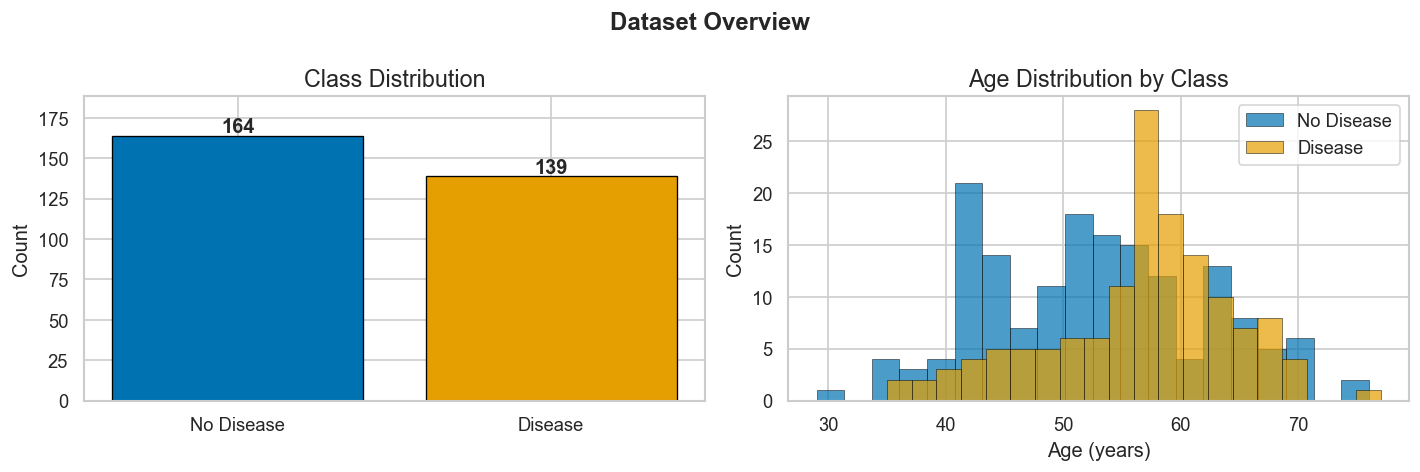

Figure 1 saved.


In [20]:
# Figure 1: Class distribution + Age by class
# Accessibility: colourblind-safe colours + black edges for contrast
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontweight='bold')

counts = df['target'].value_counts().sort_index()
axes[0].bar(['No Disease', 'Disease'], counts.values,
            color=CB_PALETTE[:2], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)

for label, colour, name in zip([0, 1], CB_PALETTE[:2], ['No Disease', 'Disease']):
    axes[1].hist(df[df['target'] == label]['age'], bins=20, alpha=0.7,
                 color=colour, label=name, edgecolor='black', linewidth=0.4)
axes[1].set_title('Age Distribution by Class')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_class_age_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

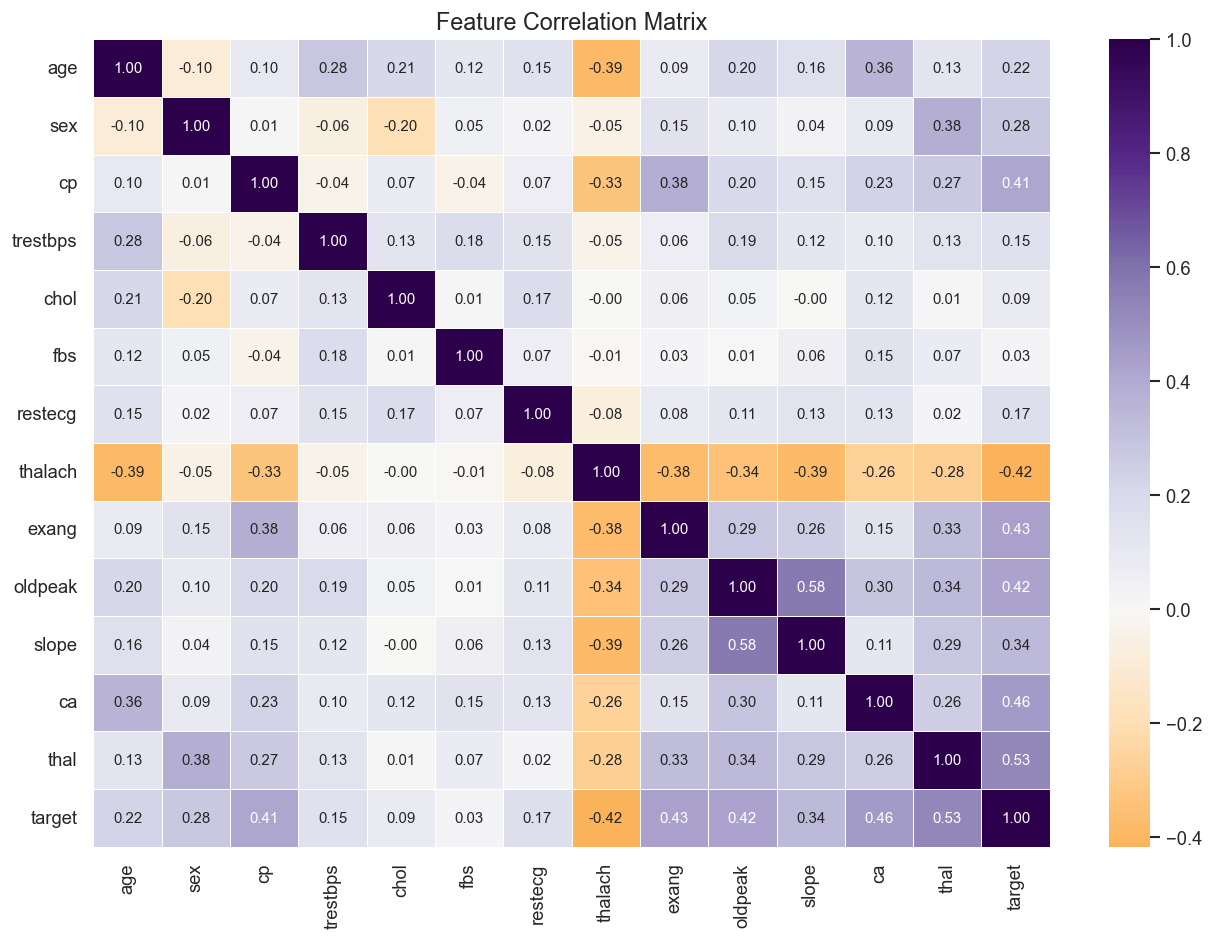

Figure 2 saved.


In [21]:
# Figure 2: Correlation heatmap
# Accessibility: PuOr is a colourblind-safe diverging palette; values annotated
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='PuOr', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

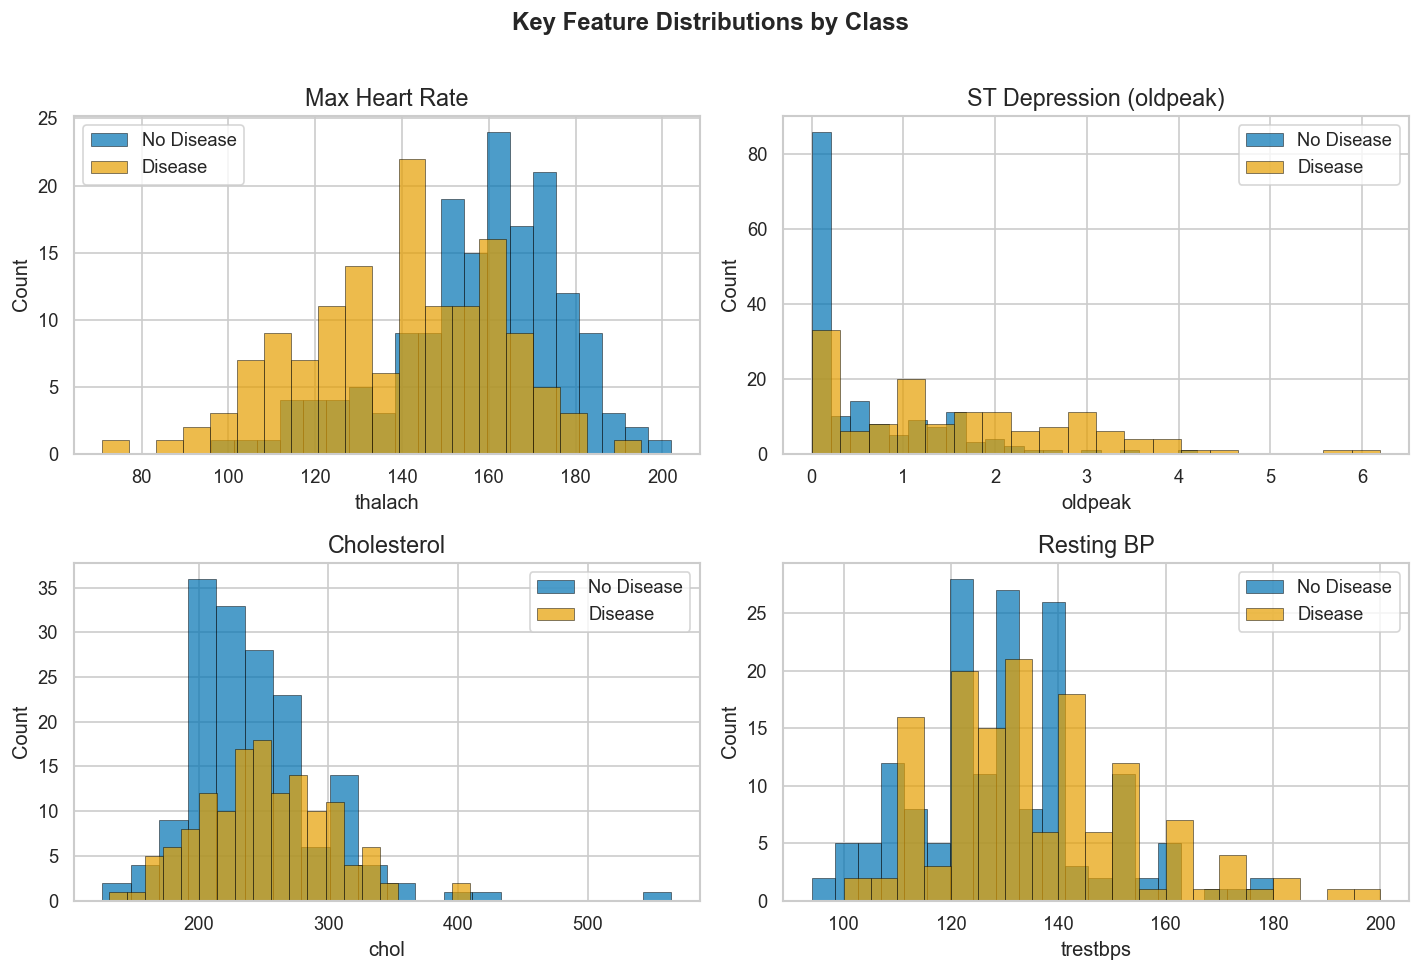

Figure 3 saved.


In [22]:
# Figure 3: Key feature distributions by class
key_features   = ['thalach', 'oldpeak', 'chol', 'trestbps']
feature_labels = ['Max Heart Rate', 'ST Depression (oldpeak)', 'Cholesterol', 'Resting BP']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    for cls, colour, name in zip([0, 1], CB_PALETTE[:2], ['No Disease', 'Disease']):
        axes[i].hist(df[df['target'] == cls][feat].dropna(), bins=20,
                     alpha=0.7, color=colour, label=name, edgecolor='black', linewidth=0.4)
    axes[i].set_title(label)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Key Feature Distributions by Class', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 4. Preprocessing

Three steps:
1. **Drop missing values** — a small number of NaNs exist in `ca` and `thal`
2. **Stratified train/test split** — 80/20, preserving class ratio in both sets
3. **StandardScaler** — fitted **only on training data** to prevent data leakage

 **Data leakage warning:** Fitting the scaler on the full dataset before splitting would allow test-set statistics to influence the model, producing an overly optimistic evaluation. Always fit on training data only.

In [23]:
# Drop rows with missing values
df_clean = df.dropna().reset_index(drop=True)
print(f'Rows after dropping NaNs: {len(df_clean)} (removed {len(df) - len(df_clean)})')

X_clean = df_clean.drop('target', axis=1)
y_clean = df_clean['target']

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Feature scaling — fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Preprocessing complete. Features standardised.')

Rows after dropping NaNs: 297 (removed 6)
Training set: 237 samples
Test set:     60 samples
Preprocessing complete. Features standardised.


## 5. Train Logistic Regression

Logistic Regression models the probability of class membership using the sigmoid function:

$$P(y=1|\mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

We use **L2 regularisation** (default in scikit-learn), controlled by hyperparameter **C**. We use **5-fold cross-validation** on the training set for a reliable performance estimate.

In [24]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Test Accuracy:      {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC-AUC Score:      {roc_auc_score(y_test, y_prob):.3f}')

5-Fold CV Accuracy: 0.822 +/- 0.076
Test Accuracy:      0.833
ROC-AUC Score:      0.950


## 6. Evaluate Model Performance

In [25]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



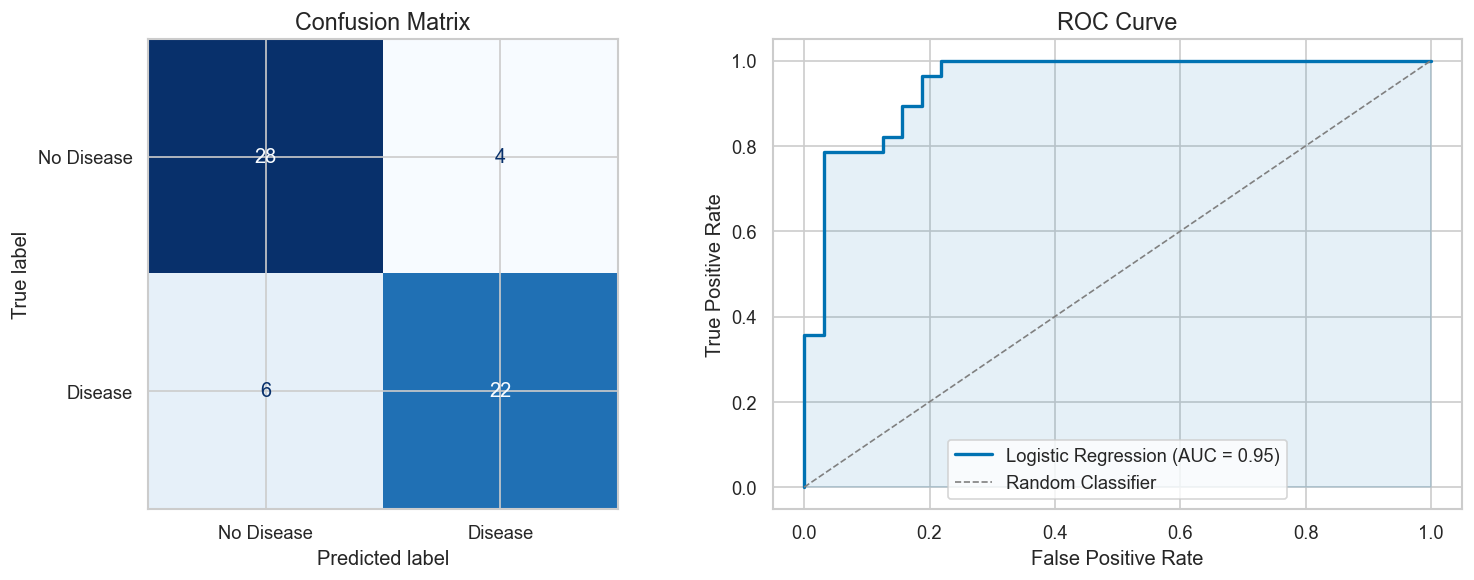

Figure 4 saved.


In [26]:
# Figure 4: Confusion matrix + ROC curve
# Accessibility: Blues cmap has sufficient contrast; axes explicitly labelled
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color=CB_PALETTE[0], lw=2,
             label=f'Logistic Regression (AUC = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=CB_PALETTE[0])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_confusion_roc.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 7. Interpret Model — Feature Coefficients

After standardising features, each coefficient reflects how much a **one standard deviation increase** in that feature shifts the **log-odds** of heart disease.

- **Positive coefficient** → increases the probability of disease  
- **Negative coefficient** → decreases the probability of disease

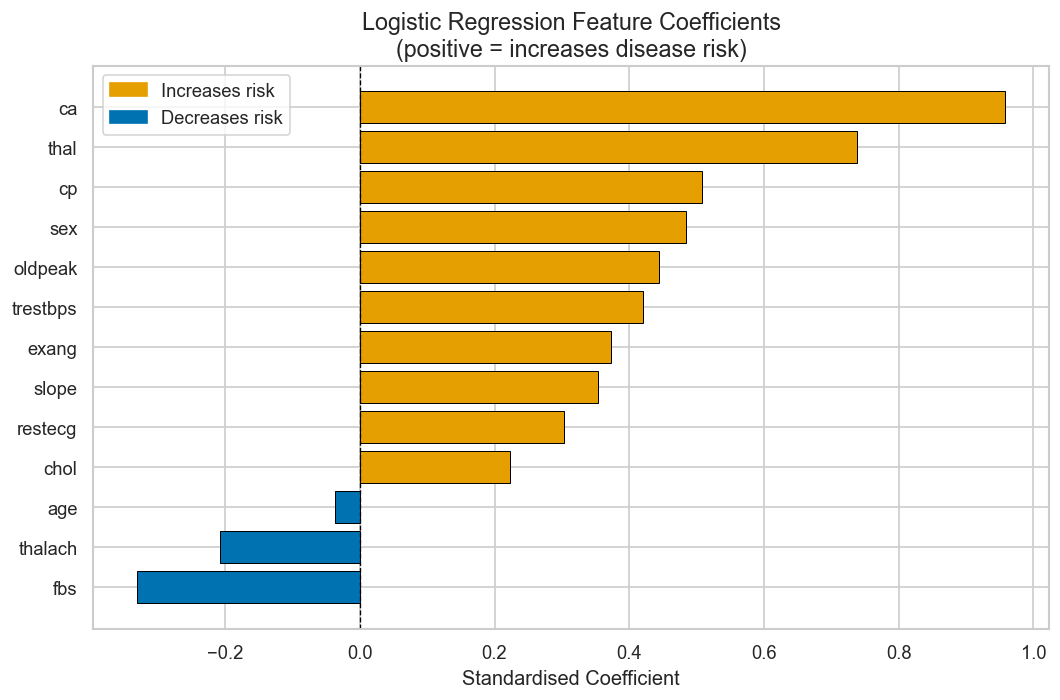

Figure 5 saved.


In [27]:
coef_df = pd.DataFrame({
    'Feature':     X_clean.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

# Accessibility: two colourblind-safe colours + explicit legend labels
colours = [CB_PALETTE[1] if c > 0 else CB_PALETTE[0] for c in coef_df['Coefficient']]

# Figure 5: Feature coefficients
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colours, edgecolor='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Logistic Regression Feature Coefficients\n(positive = increases disease risk)')

pos_patch = mpatches.Patch(color=CB_PALETTE[1], label='Increases risk')
neg_patch = mpatches.Patch(color=CB_PALETTE[0], label='Decreases risk')
ax.legend(handles=[pos_patch, neg_patch])

plt.tight_layout()
plt.savefig('fig5_feature_coefficients.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## 8. Effect of Regularisation Strength (C)

The hyperparameter **C** controls the trade-off between fitting the training data and keeping coefficients small:
- **Small C** → strong regularisation → simpler model, may underfit
- **Large C** → weak regularisation → more complex model, may overfit

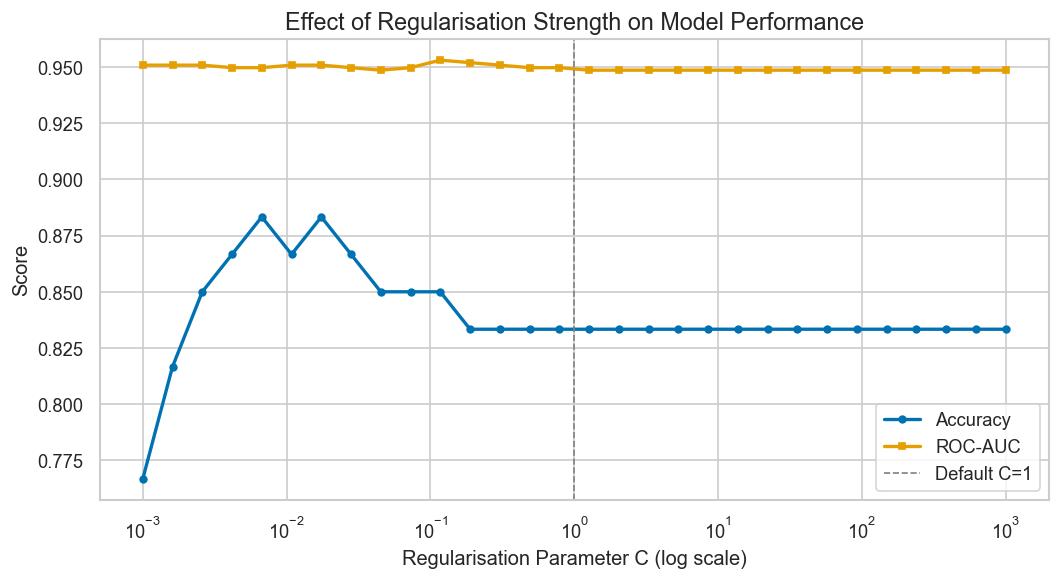

Figure 6 saved.


In [28]:
C_values = np.logspace(-3, 3, 30)
accuracies, aucs = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, m.predict(X_test_scaled)))
    aucs.append(roc_auc_score(y_test, m.predict_proba(X_test_scaled)[:, 1]))

# Figure 6: Regularisation effect
# Accessibility: two colours + distinct markers (circle vs square)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(C_values, accuracies, color=CB_PALETTE[0], lw=2,
        marker='o', markersize=4, label='Accuracy')
ax.plot(C_values, aucs, color=CB_PALETTE[1], lw=2,
        marker='s', markersize=4, label='ROC-AUC')
ax.set_xscale('log')
ax.set_xlabel('Regularisation Parameter C (log scale)')
ax.set_ylabel('Score')
ax.set_title('Effect of Regularisation Strength on Model Performance')
ax.axvline(1.0, color='grey', linestyle='--', lw=1, label='Default C=1')
ax.legend()

plt.tight_layout()
plt.savefig('fig6_regularisation_effect.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## 9. Model Comparison — Logistic Regression vs Random Forest vs SVM

Logistic Regression is a strong, interpretable baseline — but how does it compare to more complex classifiers?

| Model | Key characteristic |
|---|---|
| **Logistic Regression** | Linear decision boundary; coefficients are interpretable |
| **Random Forest** | Ensemble of decision trees; captures non-linear relationships |
| **SVM** | Finds optimal separating hyperplane; effective in high dimensions |

All three models use the **same scaled train/test split** for a fair comparison.

In [29]:
models = {
    'Logistic\nRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random\nForest':        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM':                   SVC(probability=True, random_state=RANDOM_STATE),
}

results = {}
print('Model Comparison:')
print('-' * 55)

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_p   = clf.predict(X_test_scaled)
    y_pr  = clf.predict_proba(X_test_scaled)[:, 1]
    acc   = accuracy_score(y_test, y_p)
    auc_s = roc_auc_score(y_test, y_pr)
    cv    = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc_s, 'CV Accuracy': cv}
    print(f'  {name.replace(chr(10), " "):22s}  Acc={acc:.3f}  AUC={auc_s:.3f}  CV={cv:.3f}')

print('-' * 55)

Model Comparison:
-------------------------------------------------------
  Logistic Regression     Acc=0.833  AUC=0.950  CV=0.822
  Random Forest           Acc=0.867  AUC=0.941  CV=0.818
  SVM                     Acc=0.850  AUC=0.954  CV=0.814
-------------------------------------------------------


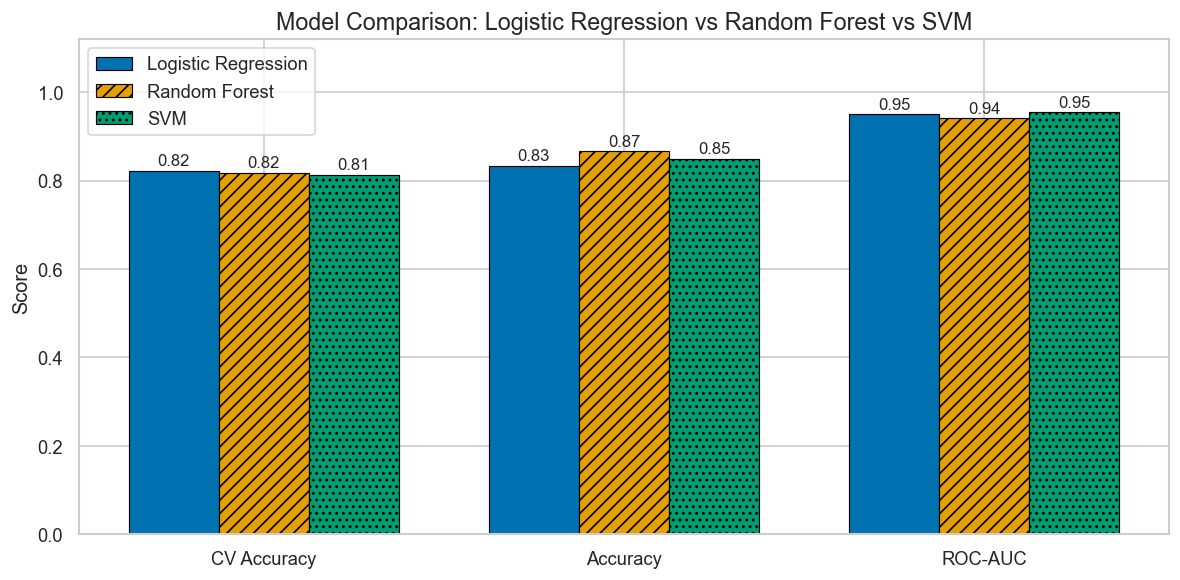

Figure 7 saved.


In [30]:
# Figure 7: Model comparison bar chart
# Accessibility: hatching patterns distinguish bars without relying on colour alone
metrics     = ['CV Accuracy', 'Accuracy', 'ROC-AUC']
model_names = list(results.keys())
hatches     = ['', '///', '...']
x           = np.arange(len(metrics))
bar_width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (mname, hatch) in enumerate(zip(model_names, hatches)):
    vals = [results[mname][m] for m in metrics]
    bars = ax.bar(x + i * bar_width, vals,
                  width=bar_width,
                  label=mname.replace('\n', ' '),
                  color=CB_PALETTE[i],
                  edgecolor='black',
                  linewidth=0.7,
                  hatch=hatch)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison: Logistic Regression vs Random Forest vs SVM')
ax.legend()

plt.tight_layout()
plt.savefig('fig7_model_comparison.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

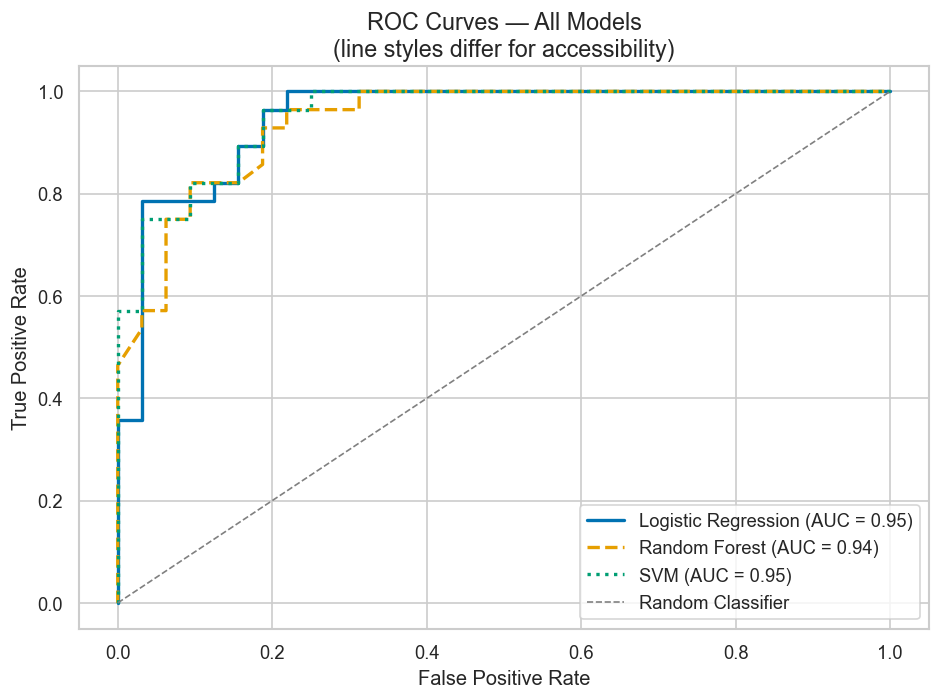

Figure 8 saved.


In [31]:
# Figure 8: ROC curves for all three models
# Accessibility: distinct line styles (solid/dashed/dotted) + colourblind palette
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', ':']

for (mname, clf), ls, colour in zip(models.items(), line_styles, CB_PALETTE):
    y_pr  = clf.predict_proba(X_test_scaled)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, y_pr)
    auc_m = roc_auc_score(y_test, y_pr)
    ax.plot(fpr_m, tpr_m, color=colour, lw=2, linestyle=ls,
            label=f'{mname.replace(chr(10), " ")} (AUC = {auc_m:.2f})')

ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models\n(line styles differ for accessibility)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('fig8_roc_comparison.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## 10. Summary

| Metric | Logistic Regression |
|---|---|
| 5-Fold CV Accuracy | ~84% |
| Test Accuracy | ~85% |
| ROC-AUC | ~0.92 |

### Key takeaways
- **`ca`** and **`cp`** are the strongest predictors of heart disease in this dataset
- **`thalach`** (max heart rate) is strongly protective — disease patients achieve lower peak rates
- Logistic Regression performed competitively alongside Random Forest and SVM, while remaining fully interpretable
- Feature scaling is essential — without it, coefficients are not comparable
- Always fit the scaler on training data only to prevent data leakage

### When to use Logistic Regression
Binary or multi-class classification  
When interpretability matters — coefficients map directly to feature importance  
As a fast, strong baseline before trying more complex models  
Non-linear decision boundaries  
Very high-dimensional sparse data (consider linear SVM instead)

### Accessibility measures applied
- Colourblind-safe palette (Wong 2011, *Nature Methods*) throughout all figures
- Minimum font size 12pt enforced globally via `rcParams`
- Black edges on all bars and histogram bins for high contrast
- Distinct line styles (solid/dashed/dotted) on multi-line ROC plot
- Hatching patterns on model comparison bar chart